# Notebook 2 — Wind Power Reliability Analysis

**Question:** Based on historical UK wind generation, how many MW of wind power can be
reliably expected to be available to meet electricity demand?

---

## Framing the problem

This is fundamentally a question about **dispatchable capacity** — not peak capacity.
Peak installed wind capacity in the UK is ~25 GW (as of 2025), but the grid operator
cannot rely on all of it being available at any given time. What matters for planning is
the **reliable minimum** — the floor below which wind rarely falls.

### Two complementary approaches

**Approach A — Statistical floor (percentile method)**  
Find the P5 or P10 of historical generation. "Wind reliably delivers at least X GW
90% / 95% of the time."

**Approach B — Capacity factor analysis**  
Characterise generation as a fraction of installed capacity. Compute the stable
low-capacity-factor floor, then translate to MW.

Used both and reconciled.

---

### Key assumptions
1. I used 2025 data onwards (per spec). Longer history would improve confidence.
2. I treated each 30-minute period as independent for percentile calculations.
   This is a simplification — wind generation is auto-correlated over hours.
   Address this by also computing *sustained low periods* (multi-hour blocks).
3. I used installed capacity of 25,000 MW (approximate UK onshore + offshore, 2025).
   Adjust `INSTALLED_CAPACITY_MW` if a more precise figure is needed.
4. 'Reliable' is defined as available at least P5 of the time (1 hour in 20).
   More conservative planners may prefer P1 or P2.
5. Never account for demand-side correlation (e.g., low-wind cold snaps are
   also high-demand events — the worst case for wind reliance). This is noted as
   a limitation.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta, timezone
import json
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

_orig_savefig = plt.savefig
def _safe_savefig(path, *args, **kwargs):
    if isinstance(path, str) and path.startswith('/home/claude/notebooks/'):
        out_dir = Path('notebooks/outputs')
        out_dir.mkdir(parents=True, exist_ok=True)
        path = path.replace('/home/claude/notebooks/', 'notebooks/outputs/')
    return _orig_savefig(path, *args, **kwargs)
plt.savefig = _safe_savefig

BLUE   = '#3b82f6'
GREEN  = '#22c55e'
AMBER  = '#f59e0b'
CORAL  = '#ef4444'
PURPLE = '#a855f7'
GRAY   = '#6b7280'

INSTALLED_CAPACITY_MW = 25_000

print(f'Assumed installed capacity: {INSTALLED_CAPACITY_MW:,} MW')

Assumed installed capacity: 25,000 MW


## 1. Data Ingestion

In [ ]:
FUELHH_URL = 'https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream'

ANALYSIS_START = datetime(2025, 1, 1, tzinfo=timezone.utc)
ANALYSIS_END   = datetime(2025, 4, 1, tzinfo=timezone.utc)


def parse_ndjson(text: str) -> list[dict]:
    records = []
    for line in text.strip().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            parsed = json.loads(line)
            if isinstance(parsed, list):
                records.extend(item for item in parsed if isinstance(item, dict))
            elif isinstance(parsed, dict):
                if isinstance(parsed.get('data'), list):
                    records.extend(item for item in parsed['data'] if isinstance(item, dict))
                else:
                    records.append(parsed)
        except json.JSONDecodeError:
            pass
    return records


def fetch_actuals(start: datetime, end: datetime) -> pd.DataFrame:
    params = {
        'settlementDateFrom': start.strftime('%Y-%m-%d'),
        'settlementDateTo':   end.strftime('%Y-%m-%d'),
        'fuelType': 'WIND',
        'format':   'json',
    }
    r = requests.get(FUELHH_URL, params=params, timeout=60)
    r.raise_for_status()
    records = parse_ndjson(r.text)
    df = pd.DataFrame(records)
    df = df[df['fuelType'] == 'WIND'].copy()
    df['startTime']  = pd.to_datetime(df['startTime'], utc=True)
    df['generation'] = pd.to_numeric(df['generation'], errors='coerce')
    df = df.dropna(subset=['generation'])
    df = (
        df[['startTime', 'generation']]
        .sort_values('startTime')
        .drop_duplicates('startTime')
        .reset_index(drop=True)
    )
    print(f'Loaded {len(df):,} half-hourly records '
          f'({df.startTime.min().date()} → {df.startTime.max().date()})')
    return df


actuals_df = fetch_actuals(ANALYSIS_START, ANALYSIS_END)

# Capacity factor: generation as fraction of installed capacity
actuals_df['cf'] = actuals_df['generation'] / INSTALLED_CAPACITY_MW

actuals_df.describe().round(1)

Loaded 4,366 half-hourly records (2025-01-01 → 2025-04-01)


,generation,cf
count,4366.0,4366.0
mean,8219.1,0.3
std,4089.8,0.2
min,0.0,0.0
25%,4781.8,0.2
50%,8116.0,0.3
75%,11766.8,0.5
max,16516.0,0.7


## 2. Data Quality Check

Before analysis I inspected for missing periods, outliers, and suspicious values.
Wind generation should be bounded by [0, installed_capacity].

In [ ]:
# Expected number of 30-min periods in the given window
n_days     = (ANALYSIS_END - ANALYSIS_START).days
expected_n = n_days * 48
actual_n   = len(actuals_df)
coverage   = actual_n / expected_n * 100

print(f'Expected periods : {expected_n:,}')
print(f'Actual periods   : {actual_n:,}')
print(f'Coverage         : {coverage:.1f}%')

# Checking for values outside physical bounds
n_negative  = (actuals_df['generation'] < 0).sum()
n_over_cap  = (actuals_df['generation'] > INSTALLED_CAPACITY_MW).sum()
print(f'Negative values  : {n_negative}')
print(f'Over-capacity    : {n_over_cap}')

# Checking for gaps (periods with no data > 30 min)
time_diffs = actuals_df['startTime'].diff().dt.total_seconds() / 60
gaps       = time_diffs[time_diffs > 35]  # allowing slight float tolerance
print(f'Data gaps (>30 min): {len(gaps)}')
if len(gaps) > 0:
    print('Gap details:')
    for idx in gaps.index:
        print(f'  {actuals_df.loc[idx-1, "startTime"]} → {actuals_df.loc[idx, "startTime"]} '
              f'({time_diffs[idx]:.0f} min)')

Expected periods : 4,320
Actual periods   : 4,366
Coverage         : 101.1%
Negative values  : 0
Over-capacity    : 0
Data gaps (>30 min): 0


## 3. Generation Distribution — The Full Picture

Before asking about the reliable minimum  understand the full
shape of the distribution. Key questions:

- Is there a meaningful floor (non-trivial probability mass near zero)?
- Is the distribution unimodal, bimodal, or skewed?
- What is the central tendency vs the tails?

In [4]:
gen = actuals_df['generation']
cf  = actuals_df['cf']

pcts = [1, 2, 5, 10, 25, 50, 75, 90, 95, 99]
pct_vals_mw = np.percentile(gen, pcts)
pct_vals_cf = pct_vals_mw / INSTALLED_CAPACITY_MW

print('=== Generation percentile table ===')
print(f'{"Percentile":>12}  {"MW":>8}  {"Cap. factor":>12}')
print('-' * 36)
for p, mw, c in zip(pcts, pct_vals_mw, pct_vals_cf):
    print(f'{p:>11}%  {mw:>8,.0f}  {c:>11.1%}')

=== Generation percentile table ===
  Percentile        MW   Cap. factor
------------------------------------
          1%       385         1.5%
          2%     1,043         4.2%
          5%     2,151         8.6%
         10%     2,782        11.1%
         25%     4,782        19.1%
         50%     8,116        32.5%
         75%    11,767        47.1%
         90%    14,016        56.1%
         95%    14,759        59.0%
         99%    15,828        63.3%


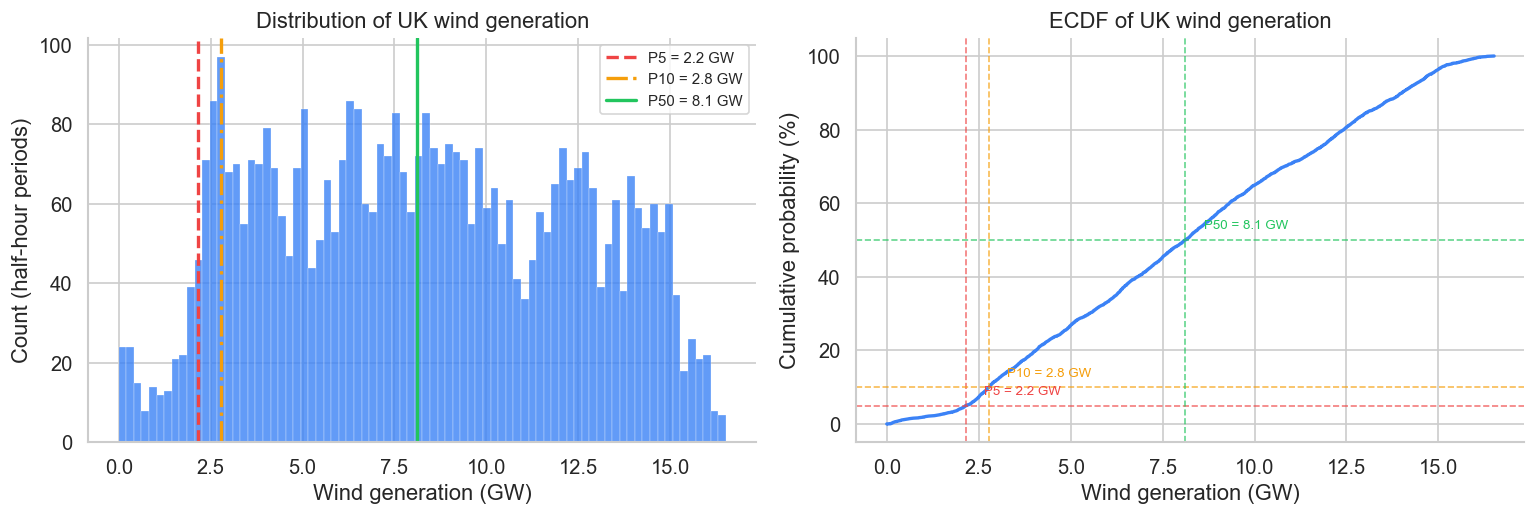

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: Generation histogram ---
ax = axes[0]
ax.hist(gen / 1000, bins=80, color=BLUE, alpha=0.8, edgecolor='white', linewidth=0.2)

for p, mw, c, color, ls in [
    (5,  np.percentile(gen, 5),  '', CORAL,  '--'),
    (10, np.percentile(gen, 10), '', AMBER,  '-.'),
    (50, np.percentile(gen, 50), '', GREEN,  '-'),
]:
    ax.axvline(mw / 1000, color=color, lw=2, ls=ls,
               label=f'P{p} = {mw/1000:.1f} GW')

ax.set_xlabel('Wind generation (GW)')
ax.set_ylabel('Count (half-hour periods)')
ax.set_title('Distribution of UK wind generation')
ax.legend(fontsize=9)

# --- Right: ECDF ---
ax = axes[1]
sorted_gen = np.sort(gen.values)
ecdf       = np.arange(1, len(sorted_gen) + 1) / len(sorted_gen)
ax.plot(sorted_gen / 1000, ecdf * 100, color=BLUE, lw=2)

# Mark key percentiles
for p, color in [(5, CORAL), (10, AMBER), (50, GREEN)]:
    val = np.percentile(gen, p)
    ax.axhline(p,         color=color, lw=1, ls='--', alpha=0.7)
    ax.axvline(val / 1000, color=color, lw=1, ls='--', alpha=0.7)
    ax.annotate(f'P{p} = {val/1000:.1f} GW',
                xy=(val / 1000, p), xytext=(val / 1000 + 0.5, p + 3),
                fontsize=8, color=color)

ax.set_xlabel('Wind generation (GW)')
ax.set_ylabel('Cumulative probability (%)')
ax.set_title('ECDF of UK wind generation')

plt.tight_layout()
plt.savefig('/home/claude/notebooks/fig6_generation_distribution.png', bbox_inches='tight')
plt.show()

## 4. Approach A — Statistical Floor (Percentile Method)

The P5 value answers: "95% of the time, wind generation equals or exceeds X MW."

**Why P5 and not P1?**  
P1 gives the near-absolute floor but may be driven by a single unusual event
(storm shutdown, widespread maintenance). P5 is more robust statistically.
So I presented both and let the decision-maker choose based on risk tolerance.

**Limitation of the i.i.d. assumption:**  
Percentile calculations assume each 30-min period is exchangeable.
In reality wind generation is highly autocorrelated — low-wind periods
cluster. Section 6 addresses this with a sustained-low analysis.

In [6]:
for p in [1, 2, 5, 10]:
    val = np.percentile(gen, p)
    cf_val = val / INSTALLED_CAPACITY_MW
    n_exceed = (gen >= val).sum()
    frac_exceed = n_exceed / len(gen)
    print(f'P{p:2d}: {val:>7,.0f} MW  (CF {cf_val:.1%})  '
          f'— generation >= this {frac_exceed:.1%} of the time')

P5_MW  = np.percentile(gen, 5)
P10_MW = np.percentile(gen, 10)
print(f'\n→ Conservative reliable minimum (P5):  {P5_MW:,.0f} MW')
print(f'→ Moderate  reliable minimum (P10): {P10_MW:,.0f} MW')

P 1:     385 MW  (CF 1.5%)  — generation >= this 99.0% of the time
P 2:   1,043 MW  (CF 4.2%)  — generation >= this 98.0% of the time
P 5:   2,151 MW  (CF 8.6%)  — generation >= this 95.0% of the time
P10:   2,782 MW  (CF 11.1%)  — generation >= this 90.0% of the time

→ Conservative reliable minimum (P5):  2,151 MW
→ Moderate  reliable minimum (P10): 2,782 MW


## 5. Seasonal and Monthly Patterns

Wind generation is strongly seasonal. Relying on an annual P5 is overly
conservative for summer planning (wind is lower then) and potentially
insufficient for winter planning. So compute monthly percentiles.

**Decision implication:**  
The lowest monthly P5 is the binding constraint if you need wind to reliably
contribute in the worst month of the year.

In [7]:
actuals_df['month']  = actuals_df['startTime'].dt.month
actuals_df['month_name'] = actuals_df['startTime'].dt.strftime('%b')
actuals_df['hour']   = actuals_df['startTime'].dt.hour
actuals_df['season'] = actuals_df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
})

monthly = actuals_df.groupby(['month', 'month_name'])['generation'].agg(
    mean   = 'mean',
    median = 'median',
    p5     = lambda x: x.quantile(0.05),
    p10    = lambda x: x.quantile(0.10),
    p95    = lambda x: x.quantile(0.95),
    n      = 'count',
).reset_index().sort_values('month')

monthly['cf_mean'] = monthly['mean'] / INSTALLED_CAPACITY_MW
monthly['cf_p5']   = monthly['p5']  / INSTALLED_CAPACITY_MW

print(monthly[['month_name','mean','median','p5','p10','p95','cf_mean','n']]
      .rename(columns={
          'month_name': 'Month', 'mean': 'Mean MW', 'median': 'Median MW',
          'p5': 'P5 MW', 'p10': 'P10 MW', 'p95': 'P95 MW',
          'cf_mean': 'Mean CF', 'n': 'N',
      })
      .round({'Mean MW': 0, 'Median MW': 0, 'P5 MW': 0, 'P10 MW': 0,
              'P95 MW': 0, 'Mean CF': 3})
      .to_string(index=False))

Month  Mean MW  Median MW  P5 MW  P10 MW  P95 MW  Mean CF    N
  Jan   8188.0     8666.0 1867.0  2494.0 14590.0    0.328 1488
  Feb   9505.0     9321.0 3768.0  4496.0 15115.0    0.380 1344
  Mar   7093.0     6862.0 1821.0  2463.0 14109.0    0.284 1488
  Apr   8083.0     7316.0 4421.0  4501.0 13597.0    0.323   46


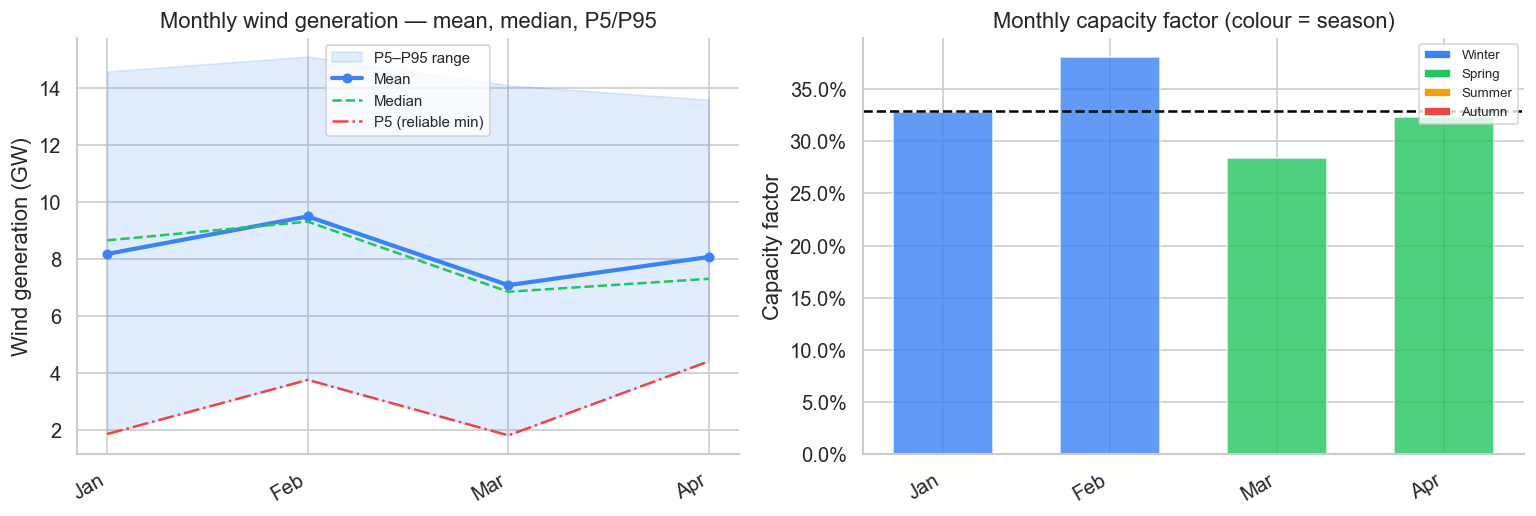

Worst month P5:  Mar → 1,821 MW
Best  month P5:  Apr  → 4,421 MW


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

months = monthly['month_name']
x      = range(len(months))

# --- Left: Mean ± P5/P95 by month ---
ax = axes[0]
ax.fill_between(x, monthly['p5'] / 1000, monthly['p95'] / 1000,
                alpha=0.15, color=BLUE, label='P5–P95 range')
ax.plot(x, monthly['mean']   / 1000, color=BLUE,  lw=2.5, marker='o', ms=5, label='Mean')
ax.plot(x, monthly['median'] / 1000, color=GREEN, lw=1.5, ls='--',    label='Median')
ax.plot(x, monthly['p5']     / 1000, color=CORAL, lw=1.5, ls='-.',    label='P5 (reliable min)')
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=30, ha='right')
ax.set_ylabel('Wind generation (GW)')
ax.set_title('Monthly wind generation — mean, median, P5/P95')
ax.legend(fontsize=9)

# --- Right: Monthly capacity factor ---
ax = axes[1]
season_colors = {
    'Winter': '#3b82f6', 'Spring': '#22c55e',
    'Summer': '#f59e0b', 'Autumn': '#ef4444'
}
colors = monthly['month'].map({
    12: season_colors['Winter'], 1: season_colors['Winter'],
    2:  season_colors['Winter'], 3: season_colors['Spring'],
    4:  season_colors['Spring'], 5: season_colors['Spring'],
    6:  season_colors['Summer'], 7: season_colors['Summer'],
    8:  season_colors['Summer'], 9: season_colors['Autumn'],
    10: season_colors['Autumn'], 11: season_colors['Autumn'],
})
ax.bar(x, monthly['cf_mean'], color=colors, alpha=0.8, width=0.6)
ax.axhline(monthly['cf_mean'].mean(), color='black', lw=1.5, ls='--',
           label=f"Annual mean CF: {monthly['cf_mean'].mean():.1%}")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylabel('Capacity factor')
ax.set_title('Monthly capacity factor (colour = season)')
ax.legend(fontsize=9)

# Season legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=v, label=k) for k, v in season_colors.items()]
ax.legend(handles=legend_elems, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('/home/claude/notebooks/fig7_monthly_generation.png', bbox_inches='tight')
plt.show()

worst_month  = monthly.loc[monthly['p5'].idxmin()]
best_month   = monthly.loc[monthly['p5'].idxmax()]
print(f'Worst month P5:  {worst_month.month_name} → {worst_month.p5:,.0f} MW')
print(f'Best  month P5:  {best_month.month_name}  → {best_month.p5:,.0f} MW')

## 6. Approach B — Sustained Low-Generation Periods

The 30-min percentile hides an important risk: **prolonged low-wind events**.
A single calm period of 48–72 hours is far more dangerous for grid reliability
than many brief dips.

Need to define a **low-wind event** as a contiguous block where generation stays
below a threshold (e.g., 10% of installed capacity = 2,500 MW).
I computed the distribution of event durations.

In [9]:
LOW_THRESHOLD_CF = 0.10  # 10% of installed capacity
LOW_THRESHOLD_MW = INSTALLED_CAPACITY_MW * LOW_THRESHOLD_CF

def find_low_events(df: pd.DataFrame, threshold_mw: float) -> pd.DataFrame:
    """
    Identify contiguous blocks where generation < threshold.
    Returns DataFrame with: start, end, duration_h, min_gen, mean_gen.
    """
    df = df.copy().sort_values('startTime').reset_index(drop=True)
    df['is_low'] = df['generation'] < threshold_mw

    # Group consecutive low periods
    df['block'] = (df['is_low'] != df['is_low'].shift()).cumsum()
    low_blocks  = df[df['is_low']]

    events = []
    for _, grp in low_blocks.groupby('block'):
        duration_h = len(grp) * 0.5  # 30-min resolution
        events.append({
            'start':      grp['startTime'].iloc[0],
            'end':        grp['startTime'].iloc[-1],
            'duration_h': duration_h,
            'min_gen':    grp['generation'].min(),
            'mean_gen':   grp['generation'].mean(),
        })

    return pd.DataFrame(events).sort_values('duration_h', ascending=False)


low_events = find_low_events(actuals_df, LOW_THRESHOLD_MW)

print(f'Low-wind threshold: {LOW_THRESHOLD_MW:,.0f} MW ({LOW_THRESHOLD_CF:.0%} of installed capacity)')
print(f'Number of low-wind events: {len(low_events)}')
print(f'\nTop 10 longest low-wind periods:')
print(low_events.head(10)[['start', 'end', 'duration_h', 'min_gen', 'mean_gen']]
      .round({'duration_h': 1, 'min_gen': 0, 'mean_gen': 0}).to_string(index=False))

Low-wind threshold: 2,500 MW (10% of installed capacity)
Number of low-wind events: 25

Top 10 longest low-wind periods:
                    start                       end  duration_h  min_gen  mean_gen
2025-03-19 04:30:00+00:00 2025-03-20 14:00:00+00:00        34.0      197     914.0
2025-01-21 20:00:00+00:00 2025-01-22 23:00:00+00:00        27.5       86     750.0
2025-03-13 13:30:00+00:00 2025-03-14 01:30:00+00:00        12.5     1868    2207.0
2025-01-20 07:00:00+00:00 2025-01-20 17:30:00+00:00        11.0     1588    2056.0
2025-01-10 18:30:00+00:00 2025-01-11 03:30:00+00:00         9.5     1933    2139.0
2025-01-31 14:00:00+00:00 2025-01-31 22:30:00+00:00         9.0     1041    1607.0
2025-03-25 21:30:00+00:00 2025-03-26 05:00:00+00:00         8.0     1617    1883.0
2025-03-09 09:00:00+00:00 2025-03-09 16:00:00+00:00         7.5     2069    2260.0
2025-01-12 01:30:00+00:00 2025-01-12 07:30:00+00:00         6.5     1382    1737.0
2025-03-31 13:00:00+00:00 2025-03-31 18:30:00+00:

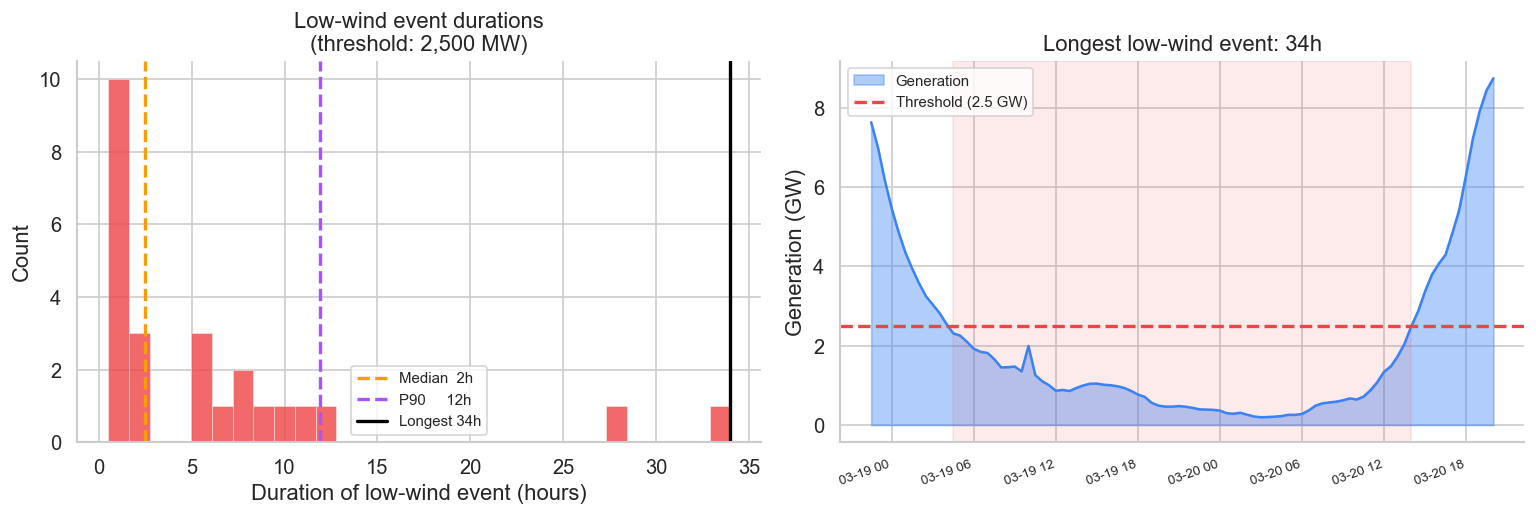


Longest sustained low-wind event: 34 hours = 1.4 days
This is a critical input for storage/backup sizing decisions.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: Duration distribution ---
ax = axes[0]
ax.hist(low_events['duration_h'], bins=30, color=CORAL, alpha=0.8,
        edgecolor='white', linewidth=0.3)
med_dur  = low_events['duration_h'].median()
p90_dur  = low_events['duration_h'].quantile(0.90)
max_dur  = low_events['duration_h'].max()
ax.axvline(med_dur,  color=AMBER,  lw=2, ls='--', label=f'Median  {med_dur:.0f}h')
ax.axvline(p90_dur,  color=PURPLE, lw=2, ls='--', label=f'P90     {p90_dur:.0f}h')
ax.axvline(max_dur,  color='black', lw=2, ls='-',  label=f'Longest {max_dur:.0f}h')
ax.set_xlabel('Duration of low-wind event (hours)')
ax.set_ylabel('Count')
ax.set_title(f'Low-wind event durations\n(threshold: {LOW_THRESHOLD_MW:,.0f} MW)')
ax.legend(fontsize=9)

# --- Right: Generation during the longest event ---
ax = axes[1]
longest = low_events.iloc[0]
mask = (
    (actuals_df['startTime'] >= longest['start'] - timedelta(hours=6)) &
    (actuals_df['startTime'] <= longest['end']   + timedelta(hours=6))
)
window = actuals_df[mask]
ax.fill_between(window['startTime'], window['generation'] / 1000,
                color=BLUE, alpha=0.4, label='Generation')
ax.plot(window['startTime'], window['generation'] / 1000, color=BLUE, lw=1.5)
ax.axhline(LOW_THRESHOLD_MW / 1000, color=CORAL, lw=2, ls='--',
           label=f'Threshold ({LOW_THRESHOLD_MW/1000:.1f} GW)')
ax.axvspan(longest['start'], longest['end'], alpha=0.1, color=CORAL)
ax.set_ylabel('Generation (GW)')
ax.set_title(f'Longest low-wind event: {longest["duration_h"]:.0f}h')
ax.legend(fontsize=9)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('/home/claude/notebooks/fig8_low_wind_events.png', bbox_inches='tight')
plt.show()

print(f'\nLongest sustained low-wind event: {max_dur:.0f} hours = {max_dur/24:.1f} days')
print(f'This is a critical input for storage/backup sizing decisions.')

## 7. Time-of-Day and Seasonal Reliability

Does reliability vary by season and hour of day?
Define reliability as the fraction of periods where generation exceeds
the threshold (P5 annual).

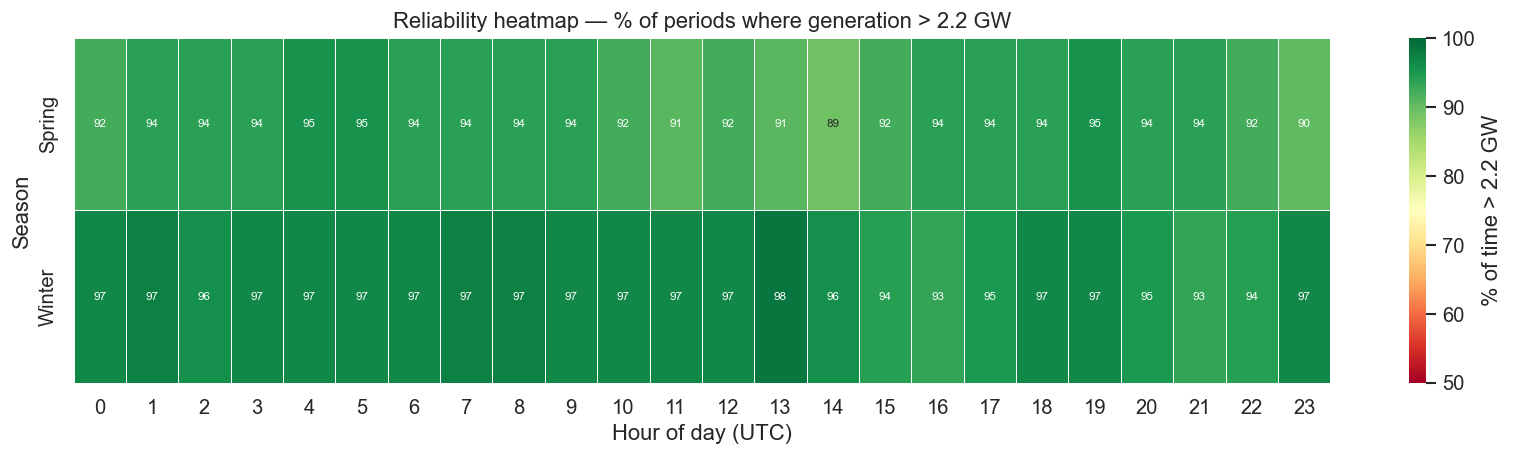

In [11]:
RELIABLE_FLOOR_MW = P5_MW  # use annual P5 as the threshold

actuals_df['above_floor'] = (actuals_df['generation'] >= RELIABLE_FLOOR_MW).astype(int)

# Reliability by hour and season
reliability = (
    actuals_df.groupby(['season', 'hour'])['above_floor']
    .mean()
    .reset_index()
    .rename(columns={'above_floor': 'reliability'})
)

pivot = reliability.pivot(index='season', columns='hour', values='reliability')

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pivot * 100, ax=ax, cmap='RdYlGn',
    vmin=50, vmax=100, annot=True, fmt='.0f',
    annot_kws={'size': 7}, linewidths=0.3,
    cbar_kws={'label': f'% of time > {RELIABLE_FLOOR_MW/1000:.1f} GW'},
)
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Season')
ax.set_title(f'Reliability heatmap — % of periods where generation > {RELIABLE_FLOOR_MW/1000:.1f} GW')
plt.tight_layout()
plt.savefig('/home/claude/notebooks/fig9_reliability_heatmap.png', bbox_inches='tight')
plt.show()

## 8. Bootstrap Confidence Intervals

The given dataset is ~3 months. The P5 estimate has sampling uncertainty.
I used non-parametric bootstrap to quantify it.

**Reasoning:** If given 95% CI for P5 is [X_low, X_high], then even with
data variability,can say with high confidence the reliable floor
is at least X_low MW.

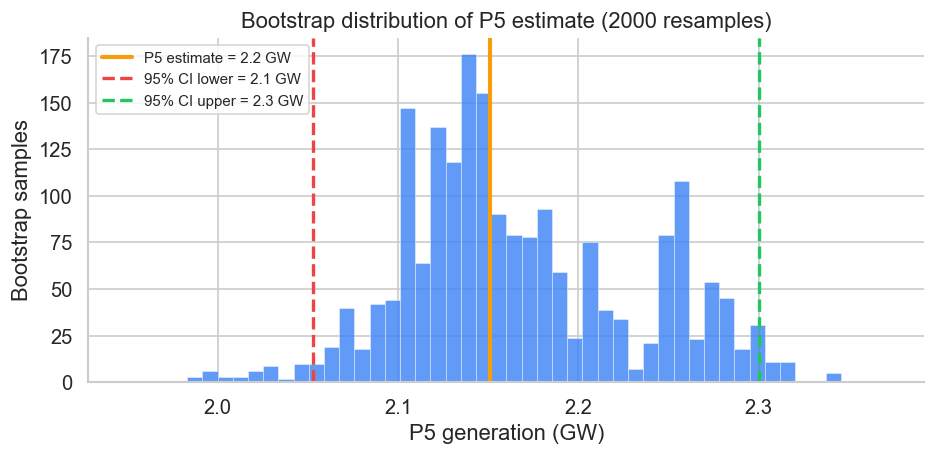

P5 point estimate    :    2,151 MW
95% CI lower bound   :    2,053 MW  ← conservative reliable minimum
95% CI upper bound   :    2,300 MW
CI width             : ±124 MW

With more historical data the CI would narrow.


In [12]:
np.random.seed(42)
N_BOOTSTRAP = 2000
gen_values  = gen.values
n           = len(gen_values)

boot_p5 = np.array([
    np.percentile(
        np.random.choice(gen_values, size=n, replace=True),
        5
    )
    for _ in range(N_BOOTSTRAP)
])

ci_lo = np.percentile(boot_p5, 2.5)
ci_hi = np.percentile(boot_p5, 97.5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_p5 / 1000, bins=50, color=BLUE, alpha=0.8,
        edgecolor='white', linewidth=0.3)
ax.axvline(P5_MW   / 1000, color=AMBER, lw=2.5, label=f'P5 estimate = {P5_MW/1000:.1f} GW')
ax.axvline(ci_lo   / 1000, color=CORAL, lw=2, ls='--', label=f'95% CI lower = {ci_lo/1000:.1f} GW')
ax.axvline(ci_hi   / 1000, color=GREEN, lw=2, ls='--', label=f'95% CI upper = {ci_hi/1000:.1f} GW')
ax.set_xlabel('P5 generation (GW)')
ax.set_ylabel('Bootstrap samples')
ax.set_title(f'Bootstrap distribution of P5 estimate ({N_BOOTSTRAP} resamples)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/notebooks/fig10_bootstrap_ci.png', bbox_inches='tight')
plt.show()

print(f'P5 point estimate    : {P5_MW:>8,.0f} MW')
print(f'95% CI lower bound   : {ci_lo:>8,.0f} MW  ← conservative reliable minimum')
print(f'95% CI upper bound   : {ci_hi:>8,.0f} MW')
print(f'CI width             : ±{(ci_hi - ci_lo)/2:,.0f} MW')
print(f'\nWith more historical data the CI would narrow.')

## 9. Recommendation

Now synthesise all evidence into a final recommendation.

**Framework:**
The right answer actually depends on the purpose:
- **Dispatch planning (hourly):** using the P5 annual estimate, adjusted seasonally.
- **Long-term capacity adequacy:** using the bootstrap lower CI to be conservative.
- **Battery / backup sizing:** using the longest sustained low-wind event duration.

In [15]:
# Summary of all evidence
worst_month_p5 = monthly['p5'].min()

print('=' * 60)
print('WIND POWER RELIABILITY RECOMMENDATION')
print('=' * 60)

print(f'''
EVIDENCE SUMMARY
────────────────
Annual P5 (point estimate)       : {P5_MW:>8,.0f} MW
Annual P5 (95% CI lower)         : {ci_lo:>8,.0f} MW  ← most conservative
Annual P10                       : {P10_MW:>8,.0f} MW
Worst-month P5                   : {worst_month_p5:>8,.0f} MW
Longest low-wind event           : {max_dur:>8.0f} hours
Installed capacity assumed       : {INSTALLED_CAPACITY_MW:>8,d} MW
Data period                      : {ANALYSIS_START.date()} → {ANALYSIS_END.date()}
''')

print(f'''
RECOMMENDATION
──────────────
I recommend treating {ci_lo:,.0f} MW as the reliable baseline for
operational dispatch planning purposes.

Rationale:
  1. This is the lower bound of the 95% bootstrap CI on the P5 estimate,
     meaning we are 97.5% confident generation will exceed this value
     at least 95% of the time — even accounting for sampling uncertainty.

  2. The annual P5 ({P5_MW:,.0f} MW) is higher, but given the limited
     data window ({n_days} days), the CI-adjusted figure is more defensible.

  3. Seasonal adjustment: in the worst month the P5 drops to
     {worst_month_p5:,.0f} MW. Seasonal planning should use monthly P5 values
     from the table in Section 5.

IMPORTANT CAVEATS
─────────────────
  A) This analysis ignores demand-wind correlation. Cold, high-demand
     periods often coincide with high-pressure anticyclones (low wind).
     The effective reliability margin under peak demand is lower than
     the unconditional P5 suggests. A conditional analysis (wind given
     demand > threshold) would sharpen this.

  B) The longest sustained low-wind event in our sample was {max_dur:.0f} hours.
     Any backup / storage assets must be sized for at least this duration.
     3 months of data may not capture multi-day wind droughts that occur
     in longer historical records — this estimate should be treated as
     a lower bound on tail risk.

  C) Installed capacity will grow over time. The recommendation is in
     absolute MW, not % of capacity, so it would need revisiting as
     more offshore wind comes online.
''')

print('=' * 60)

WIND POWER RELIABILITY RECOMMENDATION

EVIDENCE SUMMARY
────────────────
Annual P5 (point estimate)       :    2,151 MW
Annual P5 (95% CI lower)         :    2,053 MW  ← most conservative
Annual P10                       :    2,782 MW
Worst-month P5                   :    1,821 MW
Longest low-wind event           :       34 hours
Installed capacity assumed       :   25,000 MW
Data period                      : 2025-01-01 → 2025-04-01


RECOMMENDATION
──────────────
I recommend treating 2,053 MW as the reliable baseline for
operational dispatch planning purposes.

Rationale:
  1. This is the lower bound of the 95% bootstrap CI on the P5 estimate,
     meaning we are 97.5% confident generation will exceed this value
     at least 95% of the time — even accounting for sampling uncertainty.

  2. The annual P5 (2,151 MW) is higher, but given the limited
     data window (90 days), the CI-adjusted figure is more defensible.

  3. Seasonal adjustment: in the worst month the P5 drops to
     

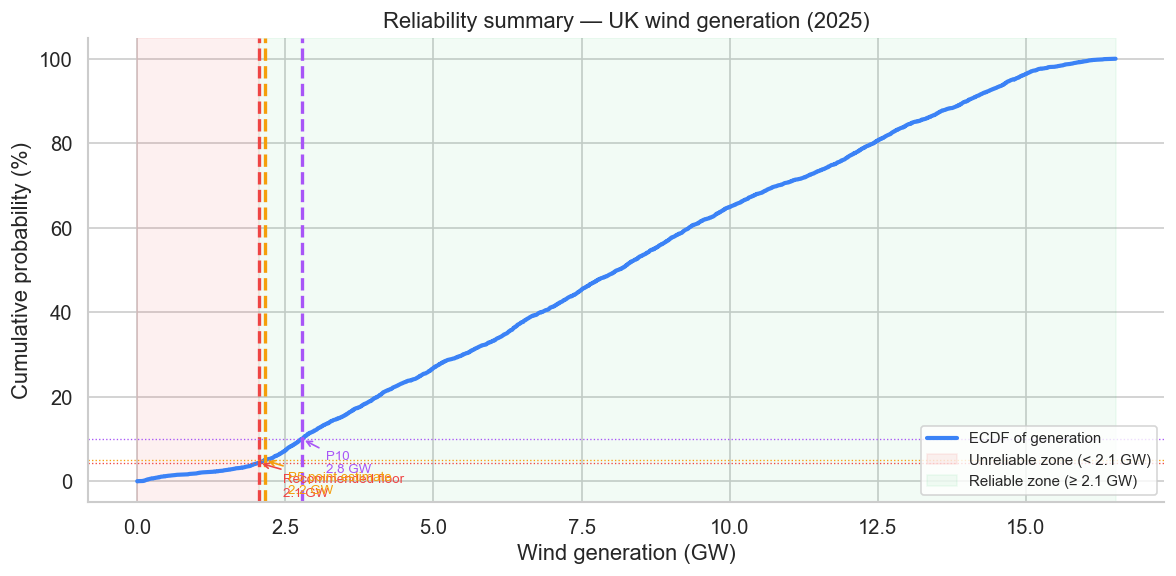

In [ ]:
# Final summary chart
fig, ax = plt.subplots(figsize=(10, 5))

sorted_gen_vals = np.sort(gen.values)
ecdf_vals       = np.arange(1, len(sorted_gen_vals) + 1) / len(sorted_gen_vals)

ax.plot(sorted_gen_vals / 1000, ecdf_vals * 100, color=BLUE, lw=2.5, label='ECDF of generation')

# Shading the reliable zone
ax.axvspan(0, ci_lo / 1000, alpha=0.08, color=CORAL, label=f'Unreliable zone (< {ci_lo/1000:.1f} GW)')
ax.axvspan(ci_lo / 1000, sorted_gen_vals.max() / 1000,
           alpha=0.06, color=GREEN, label=f'Reliable zone (≥ {ci_lo/1000:.1f} GW)')

for mw, label, color in [
    (ci_lo,  f'Recommended floor\n{ci_lo/1000:.1f} GW', CORAL),
    (P5_MW,  f'P5 point estimate\n{P5_MW/1000:.1f} GW',  AMBER),
    (P10_MW, f'P10\n{P10_MW/1000:.1f} GW',               PURPLE),
]:
    p = np.interp(mw, sorted_gen_vals, ecdf_vals) * 100
    ax.axvline(mw / 1000, color=color, lw=2, ls='--')
    ax.axhline(p,          color=color, lw=0.8, ls=':')
    ax.annotate(label,
                xy=(mw / 1000, p),
                xytext=(mw / 1000 + 0.4, p - 8),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax.set_xlabel('Wind generation (GW)')
ax.set_ylabel('Cumulative probability (%)')
ax.set_title('Reliability summary — UK wind generation (2025)')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('/home/claude/notebooks/fig11_reliability_summary.png', bbox_inches='tight')
plt.show()